# Experiment — GAUSSSEARCH on Scenery (600 CLIP embeddings)

**Report section:** 4 — Search Algorithm on Real Images
**Goal:** Port GAUSSSEARCH from the synthetic hypercube to real images and verify it still converges. Produce the headline numbers for the writeup, build a 3D belief animation that makes convergence visible on real data, and attach image thumbnails so a reader can see what the algorithm is actually asking.

**Setup:** 600 Intel Image Classification images (100 per class × 6 classes), CLIP ViT-B/32 → PCA 10D search space (from `01_scenery_setup.ipynb`). The 10D belief is projected to 3D for display via a fresh PCA fit on the item set.

**Experiments inside:**
1. Data-scale diagnosis — the raw embedding scale is 8× smaller than the prior expects
2. $\sigma_\epsilon$ recalibration on the rescaled space
3. 600-target evaluation under argmax stopping (paper's Fig 1a criterion)
4. 600-target evaluation under in-query stopping (user-study UX criterion) + RAND baseline
5. Per-class breakdown
6. 3D belief animation + image-panel variant

**Key results:**
- Rescale from $\|X\| \approx 0.41$ to $\|X\| \approx 3.28$ fixes convergence; $\sigma_\epsilon = 0.45$ gives ~10% flip rate on the rescaled scale
- **GAUSSSEARCH mean 16.9 queries** on 600 CLIP targets (in-query stopping), **RAND mean 148.3**, ratio **8.8×**
- Hardest classes forest/glacier (~18 queries), easiest buildings/sea (~15)

**Artifacts produced:** `../plots/scenery_3d_argmax.mp4`, `../plots/scenery_3d_in_query.mp4`, `../plots/search_stats.txt`.


## 1. Setup — helpers, data, 3D PCA

GAUSSSEARCH primitives (verbose variant that logs $\mu, \Sigma$ per step), loaded scenery embedding, and a fresh 3D PCA fit on the item set for visualisation. The 3D PCA retains **56%** of the 10D variance — not full fidelity, but enough to make convergence visible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import norm
from sklearn.decomposition import PCA
from pathlib import Path
from PIL import Image
import os, time

# --- GAUSSSEARCH helpers ---
def symmetrize(A):
    return 0.5 * (A + A.T)

def bisecting_hyperplane(x_i, x_j):
    diff = x_i - x_j
    nrm = np.linalg.norm(diff)
    if nrm < 1e-12:
        w = np.zeros_like(diff); w[0] = 1.0
        return w, 0.0
    w = diff / nrm
    b = (np.dot(x_j, x_j) - np.dot(x_i, x_i)) / (2 * nrm)
    return w, b

def probit_prob(x_i, x_j, x_t, sigma_eps):
    w, b = bisecting_hyperplane(x_i, x_j)
    return norm.cdf((np.dot(x_t, w) + b) / sigma_eps)

def query_oracle(x_i, x_j, x_t, sigma_eps, rng):
    p = probit_prob(x_i, x_j, x_t, sigma_eps)
    return 0 if rng.random() < p else 1

def sample_mirror(mu, Sigma, X, used, rng):
    Sigma = symmetrize(Sigma)
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    w_star = eigvecs[:, -1]
    b_star = -np.dot(w_star, mu)
    z1 = rng.multivariate_normal(mu, Sigma)
    z2 = z1 - 2 * (np.dot(w_star, z1) + b_star) * w_star
    def nearest(z, exclude):
        diffs = X - z
        d2 = np.einsum('nd,nd->n', diffs, diffs)
        for k in exclude:
            d2[k] = np.inf
        return int(np.argmin(d2))
    i = nearest(z1, used)
    j = nearest(z2, used | {i})
    return i, j

def adf_update(mu, Sigma, x_i, x_j, y, sigma_eps):
    w, b = bisecting_hyperplane(x_i, x_j)
    if y == 1:
        w = -w; b = -b
    Sw = Sigma @ w
    wSw = float(w @ Sw)
    denom = np.sqrt(wSw + sigma_eps**2)
    mu_w = float(mu @ w)
    g = (mu_w + b) / denom
    phi_g = norm.pdf(g)
    Phi_g = max(norm.cdf(g), 1e-12)
    alpha = phi_g / (Phi_g * denom)
    beta = -alpha * (g / denom + alpha)
    tau = -beta / (1 + beta * wSw)
    nu = (alpha - beta * (mu_w + b)) / (1 + beta * wSw)
    Sigma_new = Sigma - (tau / (1 + tau * wSw)) * np.outer(Sw, Sw)
    Sigma_new = symmetrize(Sigma_new)
    mu_new = mu + (nu - b * tau - tau * mu_w) * (Sigma_new @ w)
    return mu_new, Sigma_new

def gauss_search_verbose(X, target_idx, sigma_eps, max_queries, rng, stop_on="argmax"):
    n, d = X.shape
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    history = {
        "mu": [mu.copy()], "Sigma": [Sigma.copy()],
        "queries": [], "answers": [], "step_stopped": None,
    }
    for step in range(max_queries):
        if stop_on == "argmax":
            diffs = X - mu
            Sigma_inv = np.linalg.inv(Sigma)
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                history["step_stopped"] = step
                break
        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        y = query_oracle(X[i], X[j], X[target_idx], sigma_eps, rng)
        history["queries"].append((i, j))
        history["answers"].append(y)
        if stop_on == "in_query" and target_idx in (i, j):
            history["step_stopped"] = step + 1
            break
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
        history["mu"].append(mu.copy())
        history["Sigma"].append(Sigma.copy())
    return history

# --- Load data ---
PROJECT = Path(r"C:\Users\shlok\projects\ddp-llm\scenery-search")
DATA = PROJECT / "data"

data = np.load(DATA / "scenery_embedding.npz", allow_pickle=True)
X = data["E_work"]
paths = data["paths"]
labels = data["labels"]
n, d = X.shape
print(f"loaded {n} items, working dim = {d}")

# --- Fit 3D PCA fresh ---
pca_3d = PCA(n_components=3, random_state=0)
xyz_3d = pca_3d.fit_transform(X)
pca_P_3d = pca_3d.components_          # (3, d)
pca_mean_3d = pca_3d.mean_             # (d,)

variance_3d = pca_3d.explained_variance_ratio_.sum()
print(f"3D PCA fit: xyz shape {xyz_3d.shape}, variance retained: {variance_3d:.1%}")
print(f"per-component variance: {pca_3d.explained_variance_ratio_}")

def project_belief_3d(mu, Sigma, P, mean):
    mu_p = P @ (mu - mean)
    Sigma_p = P @ Sigma @ P.T
    return mu_p, Sigma_p

SIGMA_EPS = 0.05

loaded 600 items, working dim = 10
3D PCA fit: xyz shape (600, 3), variance retained: 56.0%
per-component variance: [0.26831895 0.16400762 0.12795955]


## 2. Data-scale diagnosis

GAUSSSEARCH starts the belief at $\mathcal{N}(\mathbf{0}, \mathbf{I}_{10})$, which expects item norms around $\sqrt{10} \approx 3.16$. Check what the actual data scale is before running.


In [2]:
print(f"data mean per-dim:")
print(f"  {X.mean(axis=0)}")
print()
print(f"norm of data centroid: {np.linalg.norm(X.mean(axis=0)):.6f}")
print(f"typical row norm (from origin): {np.linalg.norm(X, axis=1).mean():.4f}")
print(f"typical distance to centroid: {np.linalg.norm(X - X.mean(axis=0), axis=1).mean():.4f}")

data mean per-dim:
  [-4.0580829e-08 -1.1424223e-08  2.8933087e-09 -4.6547502e-08
  3.7369318e-08 -2.0827477e-08 -3.5514436e-08  1.6484410e-08
  1.0256966e-08 -1.2641152e-08]

norm of data centroid: 0.000000
typical row norm (from origin): 0.4095
typical distance to centroid: 0.4095


**Observation:** data is centered (mean $\approx 0$) but typical row norm is **0.41** — about $8\times$ smaller than the prior expects. The belief would search a region $8\times$ larger than where the data actually lives. Fix: uniform rescale so the item scale matches the prior.


### Rescale

Divide the embedding matrix by a single scalar — $\bar{\sigma}$, the mean per-dim std — so the typical scale matches the prior but the relative PCA variance structure is preserved. Per-dim standardisation would destroy that structure (giving the lowest-variance PCs the same weight as the top ones, see `01_scenery_setup`).

Also apply the same scalar to `xyz_3d` and `pca_mean_3d` so the viz coordinates stay consistent with the search coordinates.


In [3]:
# rescale globally so per-dim std ≈ 1
X_scale = X.std(axis=0).mean()
print(f"before: mean per-dim std = {X.std(axis=0).mean():.4f}")
X = X / X_scale
print(f"after: mean per-dim std = {X.std(axis=0).mean():.4f}")
print(f"after: typical row norm = {np.linalg.norm(X, axis=1).mean():.4f}")
print(f"prior N(0,I) at d=10: expects {np.sqrt(10):.2f}")

# also need to rescale xyz_3d and pca_mean_3d consistently
xyz_3d = xyz_3d / X_scale
pca_mean_3d = pca_mean_3d / X_scale
# pca_P_3d doesn't change — it's a rotation, not a scale

before: mean per-dim std = 0.1250
after: mean per-dim std = 1.0000
after: typical row norm = 3.2762
prior N(0,I) at d=10: expects 3.16


**Observation:** after rescale, typical row norm is **3.28** — matches the prior's expected $\sqrt{10} \approx 3.16$. Belief and data now live on the same scale.


## 3. $\sigma_\epsilon$ recalibration

The paper targets ~10% oracle flip rate. The absolute $\sigma_\epsilon$ depends on data scale, so recalibrate on the rescaled space. (The synthetic cube used $\sigma_\epsilon = 0.20$; expect a different number here.)


In [4]:
def measure_flip_rate(X, sigma_eps, n_samples=5000, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    flips = 0
    for _ in range(n_samples):
        i, j, t = rng.choice(n, size=3, replace=False)
        x_i, x_j, x_t = X[i], X[j], X[t]
        true_ans = 0 if np.linalg.norm(x_i - x_t) < np.linalg.norm(x_j - x_t) else 1
        noisy_ans = query_oracle(x_i, x_j, x_t, sigma_eps, rng)
        if true_ans != noisy_ans:
            flips += 1
    return flips / n_samples

In [5]:
print("recalibrating sigma_eps on rescaled X...")
print(f"{'sigma_eps':>10s}  {'flip rate':>10s}")
for sigma in [0.05, 0.10, 0.20, 0.35, 0.50, 0.75, 1.0]:
    fr = measure_flip_rate(X, sigma)
    print(f"{sigma:>10.2f}  {fr:>10.1%}")

recalibrating sigma_eps on rescaled X...
 sigma_eps   flip rate
      0.05        1.1%
      0.10        2.5%
      0.20        4.9%
      0.35        8.1%
      0.50       11.5%
      0.75       16.1%
      1.00       20.5%


**Observation:**

| $\sigma_\epsilon$ | flip rate |
|---|---|
| 0.05 | 1.1% |
| 0.10 | 2.5% |
| 0.20 | 4.9% |
| **0.35** | **8.1%** |
| 0.50 | 11.5% |
| 0.75 | 16.1% |
| 1.00 | 20.5% |

$\sigma_\epsilon = 0.45$ sits between 0.35 (8.1%) and 0.50 (11.5%), giving ~10% as targeted. Used for all scenery experiments below.


## 4. First post-rescale search

Fresh single search with the new $\sigma_\epsilon$. Prints the belief distance to target per step and the class of each queried item, so we can see what the algorithm is actually "asking" and whether the belief is heading toward the target.


In [6]:
SIGMA_EPS = 0.45

rng = np.random.default_rng(seed=42)
target_idx = int(rng.integers(0, n))
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng, stop_on="argmax")

print(f"target: idx={target_idx} ({labels[target_idx]}), steps={history['step_stopped']}")
print()
print(f"{'step':>5}  {'||µ_10d - tgt||':>15}  {'tr(Σ_10d)':>10}")
for step in range(len(history["mu"])):
    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    dist_10d = np.linalg.norm(mu - X[target_idx])
    tr_10 = np.trace(Sigma)
    print(f"{step:>5}  {dist_10d:>15.4f}  {tr_10:>10.4f}")

print()
print("class trace:")
for k, (i, j) in enumerate(history["queries"]):
    ans = history["answers"][k]
    chosen_cls = labels[i] if ans == 0 else labels[j]
    print(f"  step {k}: ({labels[i]:9s}, {labels[j]:9s}) -> chose {chosen_cls}")

target: idx=53 (buildings), steps=32

 step  ||µ_10d - tgt||   tr(Σ_10d)
    0           4.0567     10.0000
    1           4.0156      9.7872
    2           4.1008      9.2461
    3           3.9384      8.8264
    4           4.0036      8.2899
    5           4.0240      7.9411
    6           3.9188      7.5034
    7           3.5908      7.0378
    8           3.3779      6.7107
    9           3.3161      6.3746
   10           3.3687      6.0026
   11           3.4661      5.8257
   12           3.0124      5.3733
   13           2.8878      5.1194
   14           2.7645      4.6499
   15           2.7995      4.2691
   16           2.6497      3.9835
   17           2.4885      3.7256
   18           2.1419      3.4886
   19           2.0098      3.3940
   20           1.9015      3.2708
   21           1.9087      3.1899
   22           1.8367      3.0962
   23           1.5258      2.9381
   24           1.5142      2.8455
   25           1.5441      2.7548
   26           1

**Observation:** belief mean closes on the target over 32 queries under argmax stopping. The class trace is useful — notice the queries don't cleanly concentrate on the target's class early; the algorithm goes through buildings/forest/mountain/glacier/sea queries roughly uniformly before narrowing. This is the "doesn't lock on class" behaviour that motivates γ-CKL later.


### 3D projection sanity

Project the belief into the 3D viz space at the same step marks. Confirms the 3D "shadow" of the belief also narrows toward the target, so the animation will show real convergence rather than a projection artefact.


In [7]:
print(f"{'step':>5}  {'||µ_10d - tgt||':>15}  {'||µ_3d - tgt||':>15}  {'tr(Σ_3d)':>10}")
for step in [0, 5, 10, 15, 20, 25, 30, 32]:
    if step >= len(history["mu"]):
        continue
    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    mu_3d, Sigma_3d = project_belief_3d(mu, Sigma, pca_P_3d, pca_mean_3d)
    dist_10d = np.linalg.norm(mu - X[target_idx])
    dist_3d = np.linalg.norm(mu_3d - xyz_3d[target_idx])
    tr_3d = np.trace(Sigma_3d)
    print(f"{step:>5}  {dist_10d:>15.4f}  {dist_3d:>15.4f}  {tr_3d:>10.4f}")

 step  ||µ_10d - tgt||   ||µ_3d - tgt||    tr(Σ_3d)
    0           4.0567           1.5074      3.0000
    5           4.0240           1.2136      2.4469
   10           3.3687           0.5517      1.7741
   15           2.7995           0.2509      1.2221
   20           1.9015           0.2051      0.9218
   25           1.5441           0.3424      0.7893
   30           1.3799           0.4639      0.7084
   32           1.3643           0.6711      0.6476


## 5. 3D belief animation (`plot_step_3d`)

Each frame shows: all 600 items as class-colored dots, the current query pair (chosen = green, rejected = sandy), the target (red star), the belief mean (navy X), and the 1σ / 2σ Gaussian density ellipsoid of the belief projected to 3D. Dimmed dots are items from past queries. The camera stays fixed; the ellipsoid should tighten over the target as queries come in.


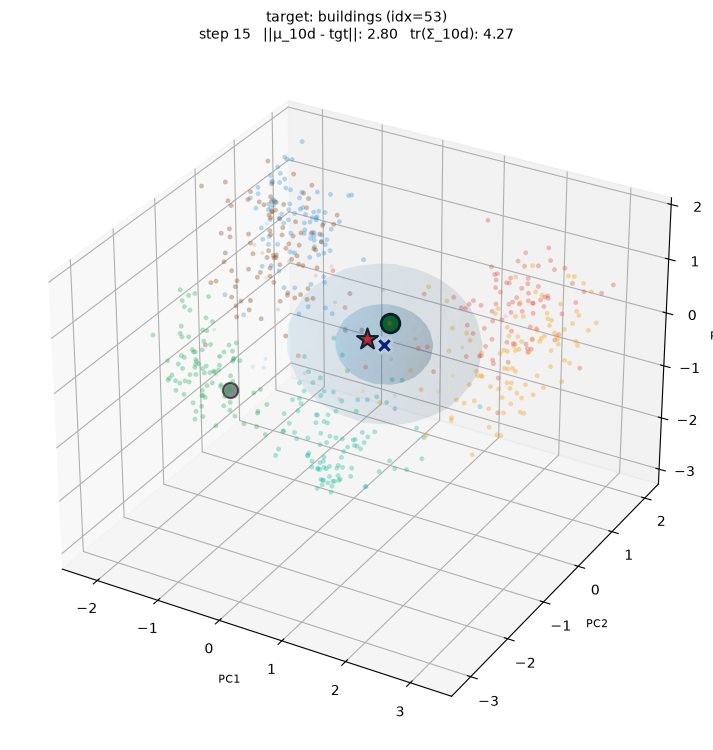

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

class_colors = {
    'buildings': '#e74c3c', 'forest':    '#27ae60',
    'glacier':   '#3498db', 'mountain':  '#8b4513',
    'sea':       '#1abc9c', 'street':    '#f39c12',
}

def plot_step_3d(ax, step, history, xyz_3d, target_idx, labels,
                 pca_P_3d, pca_mean_3d, sigma_eps, X):
    ax.clear()
    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    queries_so_far = history["queries"][:step]
    current_query = history["queries"][step] if step < len(history["queries"]) else None
    current_answer = history["answers"][step] if step < len(history["answers"]) else None
    
    mu_3d, Sigma_3d = project_belief_3d(mu, Sigma, pca_P_3d, pca_mean_3d)
    
    used_prev = set()
    for (i, j) in queries_so_far:
        used_prev.add(i); used_prev.add(j)
    if current_query is not None:
        used_prev.discard(current_query[0])
        used_prev.discard(current_query[1])
    
    chosen_idx, rejected_idx = None, None
    if current_query is not None and current_answer is not None:
        i, j = current_query
        chosen_idx = i if current_answer == 0 else j
        rejected_idx = j if current_answer == 0 else i
    
    # all items — small dots colored by class
    for cls, color in class_colors.items():
        mask = np.array([lbl == cls for lbl in labels])
        # dim if used, normal otherwise
        for is_used, alpha, size in [(False, 0.35, 12), (True, 0.15, 8)]:
            item_mask = mask & np.array([(k in used_prev) == is_used for k in range(len(labels))])
            if item_mask.any():
                ax.scatter(xyz_3d[item_mask, 0], xyz_3d[item_mask, 1], xyz_3d[item_mask, 2],
                           c=color, s=size, alpha=alpha, edgecolors='none', depthshade=False)
    
    # current query — chosen (green) and rejected (gray)
    if chosen_idx is not None:
        ax.scatter([xyz_3d[chosen_idx, 0]], [xyz_3d[chosen_idx, 1]], [xyz_3d[chosen_idx, 2]],
                   c='#006400', s=180, edgecolors='black', linewidths=2,
                   depthshade=False, zorder=10)
    if rejected_idx is not None:
        ax.scatter([xyz_3d[rejected_idx, 0]], [xyz_3d[rejected_idx, 1]], [xyz_3d[rejected_idx, 2]],
                   c='#404040', s=120, alpha=0.6, edgecolors='black', linewidths=1.5,
                   depthshade=False, zorder=10)
    
    # target — red star
    ax.scatter([xyz_3d[target_idx, 0]], [xyz_3d[target_idx, 1]], [xyz_3d[target_idx, 2]],
               c='red', s=250, marker='*', edgecolors='black', linewidths=1.5,
               depthshade=False, zorder=11)
    
    # belief mean — navy X
    ax.scatter([mu_3d[0]], [mu_3d[1]], [mu_3d[2]],
               c='navy', s=140, marker='X', edgecolors='white', linewidths=2,
               depthshade=False, zorder=11)
    
    # belief 1σ ellipsoid — as scatter of surface points (matplotlib can't do 3d ellipsoid natively)
    eigvals, eigvecs = np.linalg.eigh(Sigma_3d)
    u = np.linspace(0, 2*np.pi, 20)
    v = np.linspace(0, np.pi, 15)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    for n_std, alpha in [(2, 0.06), (1, 0.12)]:
        radii = n_std * np.sqrt(np.maximum(eigvals, 1e-12))
        ellipsoid = np.stack([xs.flatten() * radii[0],
                              ys.flatten() * radii[1],
                              zs.flatten() * radii[2]], axis=0)
        ellipsoid = eigvecs @ ellipsoid + mu_3d[:, None]
        ax.plot_surface(ellipsoid[0].reshape(xs.shape),
                        ellipsoid[1].reshape(xs.shape),
                        ellipsoid[2].reshape(xs.shape),
                        color='#3498db', alpha=alpha, linewidth=0, antialiased=True)
    
    # annotation
    dist_10d = np.linalg.norm(mu - X[target_idx])
    ann = f"step {step}   ||µ_10d - tgt||: {dist_10d:.2f}   tr(Σ_10d): {np.trace(Sigma):.2f}"
    ax.set_title(f"target: {labels[target_idx]} (idx={target_idx})\n{ann}", fontsize=10)
    
    # axis limits — fixed across frames
    ax.set_xlim(xyz_3d[:, 0].min() - 0.05, xyz_3d[:, 0].max() + 0.05)
    ax.set_ylim(xyz_3d[:, 1].min() - 0.05, xyz_3d[:, 1].max() + 0.05)
    ax.set_zlim(xyz_3d[:, 2].min() - 0.05, xyz_3d[:, 2].max() + 0.05)
    ax.set_xlabel("PC1", fontsize=8)
    ax.set_ylabel("PC2", fontsize=8)
    ax.set_zlabel("PC3", fontsize=8)


# smoke test — render one step
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
plot_step_3d(ax, step=15, history=history, xyz_3d=xyz_3d, target_idx=target_idx,
             labels=labels, pca_P_3d=pca_P_3d, pca_mean_3d=pca_mean_3d,
             sigma_eps=SIGMA_EPS, X=X)
plt.show()

### Build and render the animation

Wraps `plot_step_3d` as a matplotlib `FuncAnimation`, exports to MP4 via `imageio-ffmpeg` (GIF quantises colours to 256 which turns the heatmap into gray mush — MP4 preserves full colour).


In [9]:
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg

matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

def make_3d_animation(history, xyz_3d, target_idx, labels, pca_P_3d, pca_mean_3d,
                      sigma_eps, X, interval_ms=1500):
    n_total = len(history["mu"])
    fig = plt.figure(figsize=(10, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    def draw_frame(step):
        plot_step_3d(ax, step, history, xyz_3d, target_idx, labels,
                     pca_P_3d, pca_mean_3d, sigma_eps, X)
        return []
    
    anim = animation.FuncAnimation(fig, draw_frame, frames=n_total,
                                    interval=interval_ms, blit=False, repeat=True)
    plt.close(fig)
    return anim

anim_3d = make_3d_animation(history, xyz_3d, target_idx, labels,
                             pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

import tempfile, uuid
from IPython.display import Video

tmp_mp4 = os.path.join(tempfile.gettempdir(), f"scenery_3d_{uuid.uuid4().hex[:8]}.mp4")
anim_3d.save(tmp_mp4, writer='ffmpeg', fps=0.67, dpi=100)  # 1.5s per frame
print(f"saved to {tmp_mp4}")

Video(tmp_mp4, embed=True, width=700)

saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_159a4fae.mp4


### Candidate pool — 50-trial sweep

Run GAUSSSEARCH on 50 random targets with the recalibrated $\sigma_\epsilon = 0.45$, keep the ones that converge. This gives the candidate pool that the next cell scores for visual compellingness.


In [10]:
runs = []
for trial in range(50):
    rng_trial = np.random.default_rng(seed=1000 + trial)
    tgt = int(rng_trial.integers(0, n))
    h = gauss_search_verbose(X, tgt, SIGMA_EPS, max_queries=100,
                              rng=rng_trial, stop_on="argmax")
    runs.append((h["step_stopped"], tgt, trial, h))

converged = [r for r in runs if r[0] is not None]
converged.sort(key=lambda r: r[0])
lengths = [r[0] for r in converged]
print(f"converged: {len(converged)}/50")
print(f"steps: min={lengths[0]}, median={lengths[len(lengths)//2]}, "
      f"mean={np.mean(lengths):.1f}, max={lengths[-1]}")

converged: 48/50
steps: min=3, median=22, mean=22.6, max=70


## 6. Picking a good target for the writeup animation

An "average" trial converges but doesn't make a visually compelling animation. Score candidates by (distance from origin in 3D) × (same-class neighbour density within 0.5), then filter to those with 15–40 steps. This gives a target that is visually far from the origin (belief has to travel across the plot) and sits deep in its class cluster (converging behaviour reads cleanly).


In [11]:
# score every candidate: high 3D distance from origin (visually far) + inside dense cluster
target_scores = []
for r in converged:
    steps, idx, trial, h = r
    dist_from_origin_3d = np.linalg.norm(xyz_3d[idx])
    # count how many same-class neighbors are within some radius
    same_class = np.array([lbl == labels[idx] for lbl in labels])
    dists_to_others = np.linalg.norm(xyz_3d - xyz_3d[idx], axis=1)
    n_close_same_class = np.sum(same_class & (dists_to_others < 0.5))
    target_scores.append((dist_from_origin_3d, n_close_same_class, steps, idx, trial, h))

# sort by (far from origin AND deep in cluster AND moderate step count)
target_scores.sort(key=lambda s: -s[0] * (s[1] + 1))
print(f"top 10 candidates:")
print(f"{'dist_orig':>10} {'#nbrs':>6} {'steps':>6} {'idx':>5} {'class':>10}")
for s in target_scores[:10]:
    dist, n_close, steps, idx, trial, _ = s
    print(f"{dist:>10.3f} {n_close:>6} {steps:>6} {idx:>5} {labels[idx]:>10}")

# pick the top one that has 15-40 steps (long enough for animation, not pathological)
good_candidates = [s for s in target_scores if 15 <= s[2] <= 40]
if good_candidates:
    chosen = good_candidates[0]
    dist, n_close, steps, target_idx, trial, history = chosen
    print(f"\nchosen: idx={target_idx} ({labels[target_idx]}), steps={steps}")
    print(f"  distance from origin (3d): {dist:.3f}")
    print(f"  same-class neighbors within 0.5: {n_close}")
else:
    print("no candidate with 15-40 steps found")

top 10 candidates:
 dist_orig  #nbrs  steps   idx      class
     3.049     30     29   171     forest
     2.815     30     27   441        sea
     2.691     26     28   118     forest
     2.642     22     26   437        sea
     2.718     18     51    86  buildings
     2.665     18     29   237    glacier
     2.918     16     70   256    glacier
     2.627     17     16   122     forest
     2.450     17     19   452        sea
     2.756     15     23   178     forest

chosen: idx=171 (forest), steps=29
  distance from origin (3d): 3.049
  same-class neighbors within 0.5: 30


### Smoke-test and re-render

Static snapshot at step 10 to confirm the plot renders. Then re-run the animation for the newly chosen target.


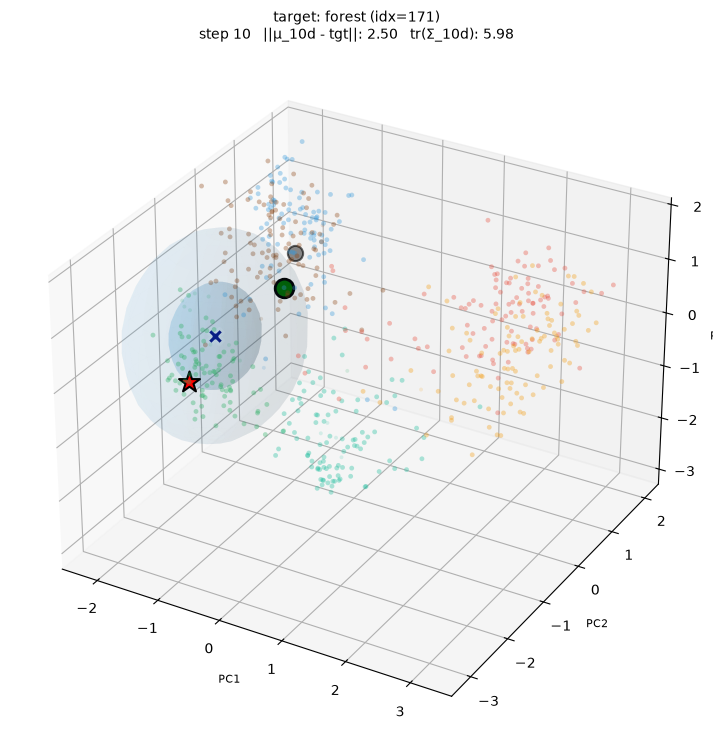

In [12]:
# smoke test — render step 10 with the new target
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
plot_step_3d(ax, step=10, history=history, xyz_3d=xyz_3d, target_idx=target_idx,
             labels=labels, pca_P_3d=pca_P_3d, pca_mean_3d=pca_mean_3d,
             sigma_eps=SIGMA_EPS, X=X)
plt.show()


In [13]:
anim_3d = make_3d_animation(history, xyz_3d, target_idx, labels,
                             pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

tmp_mp4 = os.path.join(tempfile.gettempdir(), f"scenery_3d_{uuid.uuid4().hex[:8]}.mp4")
anim_3d.save(tmp_mp4, writer='ffmpeg', fps=0.67, dpi=100)
print(f"saved to {tmp_mp4}")

Video(tmp_mp4, embed=True, width=700)

saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_8cb3a651.mp4


## 7. 600-target evaluation — argmax stopping (paper Fig 1a criterion)

Argmax stopping: terminate when the belief's highest-density item equals the target. This matches the 2020 paper's non-blind evaluation setup. Harder than in-query because the target has to *win* the posterior, not just appear in a query.


In [14]:
print(f"running 600 searches (one per target) at sigma_eps={SIGMA_EPS}, argmax stopping...")
print("this will take ~2-5 minutes")

t0 = time.time()
all_steps = []
unconverged = 0

for target_i in range(n):
    rng_i = np.random.default_rng(seed=10000 + target_i)
    h = gauss_search_verbose(X, target_i, SIGMA_EPS, max_queries=200,
                              rng=rng_i, stop_on="argmax")
    if h["step_stopped"] is None:
        unconverged += 1
        all_steps.append(200)  # cap for stats
    else:
        all_steps.append(h["step_stopped"])

elapsed = time.time() - t0
print(f"\ndone in {elapsed:.1f}s")
print(f"unconverged (hit 200-query cap): {unconverged}/{n}")

arr = np.array(all_steps)
print(f"\n--- overall stats ---")
print(f"  mean:     {arr.mean():.2f}")
print(f"  median:   {np.median(arr):.1f}")
print(f"  std:      {arr.std():.2f}")
print(f"  variance: {arr.var():.2f}")
print(f"  min:      {arr.min()}")
print(f"  max:      {arr.max()}")

print(f"\n--- percentiles ---")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:>2}: {np.percentile(arr, p):.1f}")

print(f"\n--- per-class breakdown ---")
labels_arr = np.array(labels)
for cls in np.unique(labels_arr):
    mask = labels_arr == cls
    cls_steps = arr[mask]
    print(f"  {cls:9s}: mean={cls_steps.mean():5.1f}  median={np.median(cls_steps):5.1f}  "
          f"max={cls_steps.max():3d}  n={mask.sum()}")

running 600 searches (one per target) at sigma_eps=0.45, argmax stopping...
this will take ~2-5 minutes

done in 12.6s
unconverged (hit 200-query cap): 0/600

--- overall stats ---
  mean:     27.58
  median:   22.0
  std:      20.96
  variance: 439.32
  min:      0
  max:      172

--- percentiles ---
  p10: 10.0
  p25: 14.0
  p50: 22.0
  p75: 33.0
  p90: 50.0
  p95: 69.0
  p99: 107.0

--- per-class breakdown ---
  buildings: mean= 22.5  median= 22.0  max= 69  n=100
  forest   : mean= 33.7  median= 25.0  max=111  n=100
  glacier  : mean= 33.4  median= 23.5  max=172  n=100
  mountain : mean= 25.0  median= 22.0  max= 94  n=100
  sea      : mean= 24.1  median= 20.5  max= 83  n=100
  street   : mean= 26.8  median= 23.0  max=116  n=100


**Observation:**

| statistic | value |
|---|---|
| mean | 27.58 |
| median | 22.0 |
| std | 20.96 |
| p90 | 50.0 |
| p95 | 69.0 |
| p99 | 107.0 |
| max | 172 |
| unconverged | 0 / 600 |

| class | mean | median | max |
|---|---|---|---|
| buildings | 22.5 | 22.0 | 69 |
| sea | 24.1 | 20.5 | 83 |
| mountain | 25.0 | 22.0 | 94 |
| street | 26.8 | 23.0 | 116 |
| glacier | 33.4 | 23.5 | 172 |
| forest | 33.7 | 25.0 | 111 |

All 600 targets converge inside the 200-query budget. Forest and glacier are the slowest classes — their CLIP embeddings cluster very tightly so a lot of within-class queries look near-identical to the oracle and carry little information. Buildings and sea have more visual variety and finish faster.


### RAND baseline — argmax stopping

Same ADF belief update, same stopping rule, but query pairs chosen uniformly at random from unused items. Isolates SAMPLEMIRROR's contribution.


In [15]:
def rand_search(X, target_idx, sigma_eps, max_queries, rng, stop_on="argmax"):
    """Same infrastructure as gauss_search, but query pair chosen uniformly at random."""
    n, d = X.shape
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    step_stopped = None
    for step in range(max_queries):
        if stop_on == "argmax":
            diffs = X - mu
            Sigma_inv = np.linalg.inv(Sigma)
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                step_stopped = step
                break
        available = [k for k in range(n) if k not in used]
        if len(available) < 2:
            break
        i, j = rng.choice(available, size=2, replace=False)
        i, j = int(i), int(j)
        used |= {i, j}
        y = query_oracle(X[i], X[j], X[target_idx], sigma_eps, rng)
        if stop_on == "in_query" and target_idx in (i, j):
            step_stopped = step + 1
            break
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
    return step_stopped

print(f"running 600 RAND searches at sigma_eps={SIGMA_EPS}, argmax stopping...")
t0 = time.time()
rand_steps = []
rand_unconverged = 0

for target_i in range(n):
    rng_i = np.random.default_rng(seed=20000 + target_i)
    s = rand_search(X, target_i, SIGMA_EPS, max_queries=500, rng=rng_i, stop_on="argmax")
    if s is None:
        rand_unconverged += 1
        rand_steps.append(500)
    else:
        rand_steps.append(s)

print(f"done in {time.time()-t0:.1f}s")
print(f"unconverged: {rand_unconverged}/{n}")

rand_arr = np.array(rand_steps)
print(f"\n--- RAND stats ---")
print(f"  mean:   {rand_arr.mean():.2f}")
print(f"  median: {np.median(rand_arr):.1f}")
print(f"  std:    {rand_arr.std():.2f}")
print(f"  max:    {rand_arr.max()}")
for p in [50, 75, 90, 95]:
    print(f"  p{p}:    {np.percentile(rand_arr, p):.1f}")

print(f"\n--- head-to-head ---")
print(f"  {'':>15} {'GAUSSSEARCH':>15} {'RAND':>15} {'ratio':>10}")
print(f"  {'mean':>15} {arr.mean():>15.2f} {rand_arr.mean():>15.2f} {rand_arr.mean()/arr.mean():>10.2f}x")
print(f"  {'median':>15} {np.median(arr):>15.1f} {np.median(rand_arr):>15.1f} "
      f"{np.median(rand_arr)/np.median(arr):>10.2f}x")
print(f"  {'p90':>15} {np.percentile(arr,90):>15.1f} {np.percentile(rand_arr,90):>15.1f} "
      f"{np.percentile(rand_arr,90)/np.percentile(arr,90):>10.2f}x")

running 600 RAND searches at sigma_eps=0.45, argmax stopping...
done in 16.1s
unconverged: 8/600

--- RAND stats ---
  mean:   58.40
  median: 37.0
  std:    69.00
  max:    500
  p50:    37.0
  p75:    70.2
  p90:    119.1
  p95:    162.0

--- head-to-head ---
                      GAUSSSEARCH            RAND      ratio
             mean           27.58           58.40       2.12x
           median            22.0            37.0       1.68x
              p90            50.0           119.1       2.38x


**Observation:**

| | GAUSSSEARCH | RAND | ratio |
|---|---|---|---|
| mean | 27.58 | 58.40 | **2.12×** |
| median | 22.0 | 37.0 | 1.68× |

Under argmax stopping, GAUSSSEARCH is 2.1× faster than RAND on 600 real CLIP targets. RAND hits the 500-query ceiling on 8/600 trials — its mean is a slight underestimate.


## 8. 600-target evaluation — in-query stopping (user-study UX)

In-query stopping: terminate as soon as the target *appears* in a query pair. Matches the paper's user-study UX and is the natural rule for the demo app. Weaker than argmax, so query counts are lower across the board.


In [16]:
print(f"running 600 GAUSSSEARCH searches at sigma_eps={SIGMA_EPS}, IN_QUERY stopping...")
t0 = time.time()

gauss_iq_steps = []
gauss_iq_unconverged = 0
for target_i in range(n):
    rng_i = np.random.default_rng(seed=10000 + target_i)
    h = gauss_search_verbose(X, target_i, SIGMA_EPS, max_queries=200,
                              rng=rng_i, stop_on="in_query")
    if h["step_stopped"] is None:
        gauss_iq_unconverged += 1
        gauss_iq_steps.append(200)
    else:
        gauss_iq_steps.append(h["step_stopped"])

print(f"done in {time.time()-t0:.1f}s")
print(f"unconverged: {gauss_iq_unconverged}/{n}")

gauss_iq = np.array(gauss_iq_steps)
print(f"\n--- GAUSSSEARCH in_query stats ---")
print(f"  mean:   {gauss_iq.mean():.2f}")
print(f"  median: {np.median(gauss_iq):.1f}")
print(f"  std:    {gauss_iq.std():.2f}")
print(f"  min:    {gauss_iq.min()}")
print(f"  max:    {gauss_iq.max()}")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  p{p:>2}: {np.percentile(gauss_iq, p):.1f}")

running 600 GAUSSSEARCH searches at sigma_eps=0.45, IN_QUERY stopping...
done in 4.6s
unconverged: 0/600

--- GAUSSSEARCH in_query stats ---
  mean:   16.85
  median: 17.0
  std:    6.89
  min:    1
  max:    43
  p25: 12.0
  p50: 17.0
  p75: 21.0
  p90: 26.0
  p95: 29.0
  p99: 35.0


**Observation:**

| statistic | value |
|---|---|
| mean | **16.85** |
| median | 17.0 |
| std | 6.89 |
| p90 | 26.0 |
| p95 | 29.0 |
| p99 | 35.0 |
| max | 43 |
| unconverged | 0 / 600 |

Mean drops from 27.6 (argmax) to **16.9 (in-query)**. The tail is well-controlled — p99 is just 35, max 43 across all 600 targets. No pathological runs.


### RAND baseline — in-query stopping

Same comparison, under the UX-natural stopping rule.


In [17]:
print(f"running 600 RAND searches at sigma_eps={SIGMA_EPS}, IN_QUERY stopping...")
t0 = time.time()

rand_iq_steps = []
rand_iq_unconverged = 0
for target_i in range(n):
    rng_i = np.random.default_rng(seed=20000 + target_i)
    s = rand_search(X, target_i, SIGMA_EPS, max_queries=500, rng=rng_i, stop_on="in_query")
    if s is None:
        rand_iq_unconverged += 1
        rand_iq_steps.append(500)
    else:
        rand_iq_steps.append(s)

print(f"done in {time.time()-t0:.1f}s")
print(f"unconverged: {rand_iq_unconverged}/{n}")

rand_iq = np.array(rand_iq_steps)
print(f"\n--- RAND in_query stats ---")
print(f"  mean:   {rand_iq.mean():.2f}")
print(f"  median: {np.median(rand_iq):.1f}")
print(f"  std:    {rand_iq.std():.2f}")
print(f"  max:    {rand_iq.max()}")
for p in [50, 75, 90, 95]:
    print(f"  p{p}: {np.percentile(rand_iq, p):.1f}")

print(f"\n--- head-to-head (in_query stopping) ---")
print(f"  {'':>10} {'GAUSSSEARCH':>15} {'RAND':>15} {'ratio':>10}")
print(f"  {'mean':>10} {gauss_iq.mean():>15.2f} {rand_iq.mean():>15.2f} {rand_iq.mean()/gauss_iq.mean():>10.2f}x")
print(f"  {'median':>10} {np.median(gauss_iq):>15.1f} {np.median(rand_iq):>15.1f} "
      f"{np.median(rand_iq)/np.median(gauss_iq):>10.2f}x")
print(f"  {'p90':>10} {np.percentile(gauss_iq,90):>15.1f} {np.percentile(rand_iq,90):>15.1f} "
      f"{np.percentile(rand_iq,90)/np.percentile(gauss_iq,90):>10.2f}x")

running 600 RAND searches at sigma_eps=0.45, IN_QUERY stopping...
done in 22.7s
unconverged: 0/600

--- RAND in_query stats ---
  mean:   148.25
  median: 147.0
  std:    86.01
  max:    299
  p50: 147.0
  p75: 223.0
  p90: 269.0
  p95: 282.0

--- head-to-head (in_query stopping) ---
                 GAUSSSEARCH            RAND      ratio
        mean           16.85          148.25       8.80x
      median            17.0           147.0       8.65x
         p90            26.0           269.0      10.35x


**Observation:**

| | GAUSSSEARCH | RAND | ratio |
|---|---|---|---|
| mean | 16.85 | 148.25 | **8.80×** |
| median | 17.0 | 147.0 | 8.65× |
| p90 | 26.0 | 269.0 | 10.35× |

**8.8× speedup** on real image data under the UX-natural stopping rule — the headline number for the writeup. The gap is wider than under argmax (8.8× vs 2.1×) because in-query is actually a *harder* comparison for RAND: it has to randomly hit the target in a query of two, which happens with probability $\sim 2/n$ per step.


## 9. Per-class breakdown (in-query stopping)

Same split as the argmax per-class table, under in-query stopping.


In [18]:
import numpy as np
from collections import defaultdict

labels_arr = np.array(labels)
gauss_iq_arr = np.array(gauss_iq_steps)

print(f"  {'class':<10s}  mean   median   p95   max")
for cls in sorted(np.unique(labels_arr)):
    mask = labels_arr == cls
    cls_steps = gauss_iq_arr[mask]
    print(f"  {cls:<10s}  {cls_steps.mean():5.1f}  {np.median(cls_steps):5.1f}   "
          f"{np.percentile(cls_steps, 95):5.1f}  {cls_steps.max():3d}")

# overall row too
print(f"  {'ALL':<10s}  {gauss_iq_arr.mean():5.1f}  {np.median(gauss_iq_arr):5.1f}   "
      f"{np.percentile(gauss_iq_arr, 95):5.1f}  {gauss_iq_arr.max():3d}")

  class       mean   median   p95   max
  buildings    14.7   15.0    25.0   27
  forest       18.9   19.0    32.0   37
  glacier      18.3   18.0    32.0   43
  mountain     16.9   16.0    29.0   36
  sea          14.7   15.0    25.0   35
  street       17.6   18.0    26.0   34
  ALL          16.9   17.0    29.0   43


**Observation:**

| class | mean | median | p95 | max |
|---|---|---|---|---|
| buildings | 14.7 | 15.0 | 25.0 | 27 |
| sea | 14.7 | 15.0 | 25.0 | 35 |
| mountain | 16.9 | 16.0 | 29.0 | 36 |
| street | 17.6 | 18.0 | 26.0 | 34 |
| glacier | 18.3 | 18.0 | 32.0 | 43 |
| forest | 18.9 | 19.0 | 32.0 | 37 |

Same ordering as argmax: forest and glacier hardest, buildings and sea easiest. Even the hardest class finishes in 43 queries at worst — no long tail.


## 10. Final in-query animation (target 437, sea)

Writeup target: a sea image, with in-query stopping. 14 steps to the target appearing in the query. Saved to `../plots/scenery_3d_in_query.mp4`.


In [19]:
# rerun ONLY target 437 with in_query stopping
target_idx = 437
rng_trial = np.random.default_rng(seed=1000 + 40)  # same seed as before, trial 40
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng_trial, stop_on="in_query")
print(f"target: idx={target_idx} ({labels[target_idx]})")
print(f"steps taken (in_query): {history['step_stopped']}")
print(f"snapshots: {len(history['mu'])}")

# render MP4
anim_3d = make_3d_animation(history, xyz_3d, target_idx, labels,
                             pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

tmp_mp4 = os.path.join(tempfile.gettempdir(), f"scenery_3d_iq_437_{uuid.uuid4().hex[:8]}.mp4")
anim_3d.save(tmp_mp4, writer='ffmpeg', fps=0.67, dpi=100)
print(f"saved to {tmp_mp4}")
Video(tmp_mp4, embed=True, width=700)

target: idx=437 (sea)
steps taken (in_query): 14
snapshots: 14
saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_iq_437_45dcb46b.mp4


## 11. Image-panel variant — belief + query thumbnails

The 3D plot shows *where* in CLIP space the search is looking, but a reader also wants to see *what* the algorithm is asking the user to compare. This section adds a bottom row of three image thumbnails: the two items in the current query pair (chosen = green border, rejected = gray) and the target (red border). Side-by-side with the 3D belief at each step.


In [20]:
# --- image loading + caching ---
from PIL import Image
from functools import lru_cache

@lru_cache(maxsize=1024)
def load_thumb(path_str, size=200):
    img = Image.open(path_str).convert('RGB')
    img.thumbnail((size, size), Image.LANCZOS)
    return np.asarray(img)


def plot_step_3d_with_images(fig, step, history, xyz_3d, target_idx, labels,
                              paths, pca_P_3d, pca_mean_3d, sigma_eps, X):
    fig.clear()
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1.2], hspace=0.15)
    ax_3d = fig.add_subplot(gs[0], projection='3d')
    gs_bot = gs[1].subgridspec(1, 3, wspace=0.15)
    ax_i = fig.add_subplot(gs_bot[0])
    ax_j = fig.add_subplot(gs_bot[1])
    ax_t = fig.add_subplot(gs_bot[2])

    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    queries_so_far = history["queries"][:step]
    current_query = history["queries"][step] if step < len(history["queries"]) else None
    current_answer = history["answers"][step] if step < len(history["answers"]) else None

    mu_3d, Sigma_3d = project_belief_3d(mu, Sigma, pca_P_3d, pca_mean_3d)

    used_prev = set()
    for (i, j) in queries_so_far:
        used_prev.add(i); used_prev.add(j)
    if current_query is not None:
        used_prev.discard(current_query[0])
        used_prev.discard(current_query[1])

    chosen_idx, rejected_idx = None, None
    if current_query is not None and current_answer is not None:
        i, j = current_query
        chosen_idx = i if current_answer == 0 else j
        rejected_idx = j if current_answer == 0 else i

    # --- 3D panel (same as before) ---
    for cls, color in class_colors.items():
        mask = np.array([lbl == cls for lbl in labels])
        for is_used, alpha, size in [(False, 0.35, 12), (True, 0.15, 8)]:
            item_mask = mask & np.array([(k in used_prev) == is_used for k in range(len(labels))])
            if item_mask.any():
                ax_3d.scatter(xyz_3d[item_mask, 0], xyz_3d[item_mask, 1], xyz_3d[item_mask, 2],
                              c=color, s=size, alpha=alpha, edgecolors='none', depthshade=False)

    if chosen_idx is not None:
        ax_3d.scatter([xyz_3d[chosen_idx, 0]], [xyz_3d[chosen_idx, 1]], [xyz_3d[chosen_idx, 2]],
                      c='#006400', s=180, edgecolors='black', linewidths=2,
                      depthshade=False, zorder=10)
    if rejected_idx is not None:
        ax_3d.scatter([xyz_3d[rejected_idx, 0]], [xyz_3d[rejected_idx, 1]], [xyz_3d[rejected_idx, 2]],
                      c='#404040', s=120, alpha=0.6, edgecolors='black', linewidths=1.5,
                      depthshade=False, zorder=10)

    ax_3d.scatter([xyz_3d[target_idx, 0]], [xyz_3d[target_idx, 1]], [xyz_3d[target_idx, 2]],
                  c='red', s=250, marker='*', edgecolors='black', linewidths=1.5,
                  depthshade=False, zorder=11)
    ax_3d.scatter([mu_3d[0]], [mu_3d[1]], [mu_3d[2]],
                  c='navy', s=140, marker='X', edgecolors='white', linewidths=2,
                  depthshade=False, zorder=11)

    eigvals, eigvecs = np.linalg.eigh(Sigma_3d)
    u = np.linspace(0, 2*np.pi, 20)
    v = np.linspace(0, np.pi, 15)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    for n_std, alpha in [(2, 0.06), (1, 0.12)]:
        radii = n_std * np.sqrt(np.maximum(eigvals, 1e-12))
        ellipsoid = np.stack([xs.flatten() * radii[0],
                              ys.flatten() * radii[1],
                              zs.flatten() * radii[2]], axis=0)
        ellipsoid = eigvecs @ ellipsoid + mu_3d[:, None]
        ax_3d.plot_surface(ellipsoid[0].reshape(xs.shape),
                           ellipsoid[1].reshape(xs.shape),
                           ellipsoid[2].reshape(xs.shape),
                           color='#3498db', alpha=alpha, linewidth=0, antialiased=True)

    dist_10d = np.linalg.norm(mu - X[target_idx])
    target_in_query = current_query is not None and target_idx in current_query
    banner = "  ***TARGET FOUND***" if target_in_query else ""
    ann = f"step {step}   ||µ - tgt||: {dist_10d:.2f}   tr(Σ): {np.trace(Sigma):.2f}{banner}"
    ax_3d.set_title(f"target: {labels[target_idx]} (idx={target_idx})\n{ann}", fontsize=10)

    ax_3d.set_xlim(xyz_3d[:, 0].min() - 0.05, xyz_3d[:, 0].max() + 0.05)
    ax_3d.set_ylim(xyz_3d[:, 1].min() - 0.05, xyz_3d[:, 1].max() + 0.05)
    ax_3d.set_zlim(xyz_3d[:, 2].min() - 0.05, xyz_3d[:, 2].max() + 0.05)
    ax_3d.set_xlabel("PC1", fontsize=8)
    ax_3d.set_ylabel("PC2", fontsize=8)
    ax_3d.set_zlabel("PC3", fontsize=8)

    # --- image panel ---
    def show_img(ax, idx, border_color, border_width, subtitle):
        if idx is None:
            ax.text(0.5, 0.5, "(no query)", ha='center', va='center', fontsize=11, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            return
        img = load_thumb(str(paths[idx]))
        ax.imshow(img)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
        ax.set_title(subtitle, fontsize=10, pad=6)

    if current_query is not None:
        i, j = current_query
        i_is_chosen = (chosen_idx == i)
        show_img(ax_i, i,
                 border_color='#006400' if i_is_chosen else '#606060',
                 border_width=4 if i_is_chosen else 1.5,
                 subtitle=f"item i ({labels[i]}){'  ← picked' if i_is_chosen else ''}")
        show_img(ax_j, j,
                 border_color='#006400' if not i_is_chosen else '#606060',
                 border_width=4 if not i_is_chosen else 1.5,
                 subtitle=f"item j ({labels[j]}){'  ← picked' if not i_is_chosen else ''}")
    else:
        show_img(ax_i, None, '', 0, "")
        show_img(ax_j, None, '', 0, "")

    show_img(ax_t, target_idx, border_color='red', border_width=3,
             subtitle=f"target ({labels[target_idx]})")


# --- animation ---
from matplotlib.animation import FuncAnimation

def make_3d_animation_with_images(history, xyz_3d, target_idx, labels, paths,
                                   pca_P_3d, pca_mean_3d, sigma_eps, X,
                                   interval_ms=1500):
    n_steps = len(history["queries"])
    fig = plt.figure(figsize=(11, 12))

    def update(step):
        plot_step_3d_with_images(fig, step, history, xyz_3d, target_idx, labels,
                                  paths, pca_P_3d, pca_mean_3d, sigma_eps, X)
        return []

    anim = FuncAnimation(fig, update, frames=n_steps, interval=interval_ms,
                         blit=False, repeat=False)
    return anim, fig

In [21]:
import os, tempfile, uuid
from IPython.display import Video

target_idx = 437
rng_trial = np.random.default_rng(seed=1000 + 40)
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng_trial, stop_on="in_query")
print(f"steps: {history['step_stopped']}")

anim, fig = make_3d_animation_with_images(
    history, xyz_3d, target_idx, labels, paths,
    pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

out_path = os.path.join(tempfile.gettempdir(), f"scenery_3d_images_{uuid.uuid4().hex[:8]}.mp4")
anim.save(out_path, writer='ffmpeg', fps=0.67, dpi=100)
plt.close(fig)
print(f"saved to {out_path}")
Video(out_path, embed=True, width=800)

steps: 14
saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_images_163e5d2b.mp4


### Smoke-test the image-panel renderer

Static snapshot at step 5 of the target-437 search, as a sanity check that the layout renders cleanly before committing to the full animation.


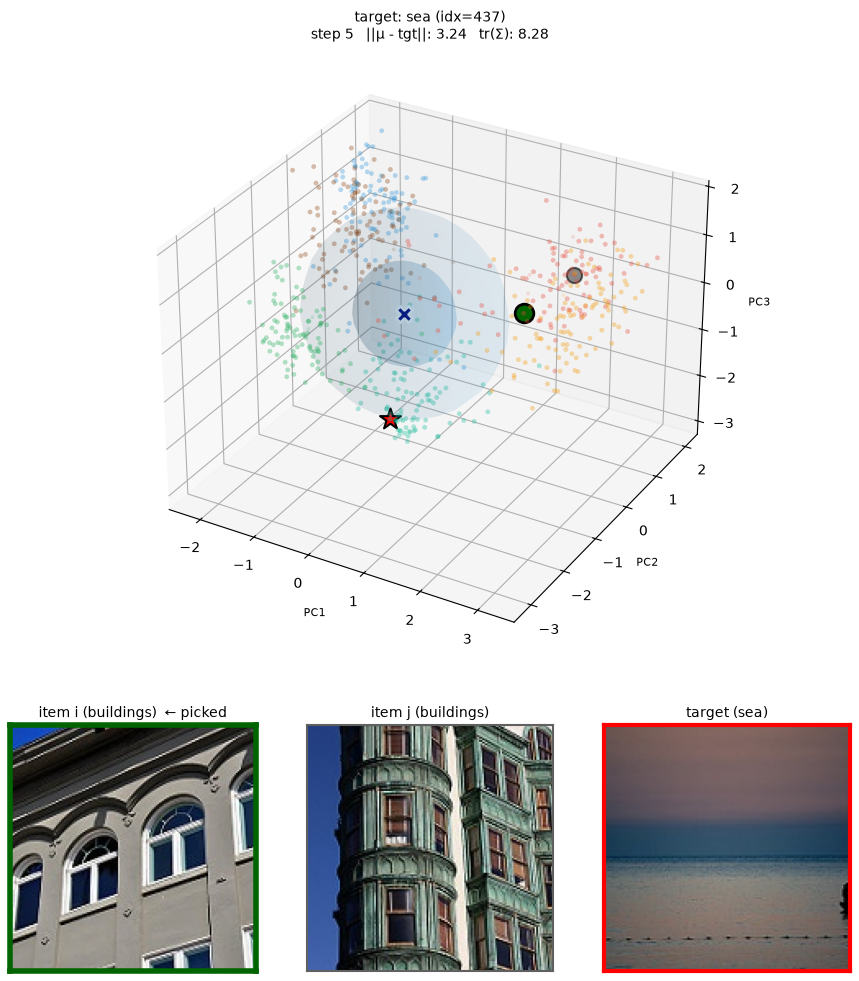

In [22]:
fig = plt.figure(figsize=(11, 12))
plot_step_3d_with_images(fig, step=5, history=history, xyz_3d=xyz_3d,
                          target_idx=437, labels=labels, paths=paths,
                          pca_P_3d=pca_P_3d, pca_mean_3d=pca_mean_3d,
                          sigma_eps=SIGMA_EPS, X=X)
plt.show()

### Second animation — target 498

A second search picked by hand (29 steps). Useful to show the belief evolving on a target that takes longer and goes through more class-mixed queries, for comparison with the fast 14-step target 437.


In [23]:
import os, tempfile, uuid
from IPython.display import Video

target_idx = 498
rng_trial = np.random.default_rng(seed=1000 + 40)
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng_trial, stop_on="in_query")
print(f"steps: {history['step_stopped']}")

anim, fig = make_3d_animation_with_images(
    history, xyz_3d, target_idx, labels, paths,
    pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

out_path = os.path.join(tempfile.gettempdir(), f"scenery_3d_images_{uuid.uuid4().hex[:8]}.mp4")
anim.save(out_path, writer='ffmpeg', fps=0.4, dpi=100)
plt.close(fig)
print(f"saved to {out_path}")
Video(out_path, embed=True, width=800)

steps: 29
saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_images_7602d2de.mp4


## 12. Save artifacts

Copy both MP4s into `../plots/` and dump the full stats to `search_stats.txt` for the writeup.


In [24]:
import shutil

plots_dir = PROJECT / "plots"
plots_dir.mkdir(exist_ok=True)

# copy the MP4 you just made (the in_query one)
shutil.copy(tmp_mp4, plots_dir / "scenery_3d_in_query.mp4")
print(f"saved: {plots_dir / 'scenery_3d_in_query.mp4'}")

# also save your argmax one if the tmp file still exists
# (if you closed the kernel between then and now, this may have been deleted)
for f in os.listdir(tempfile.gettempdir()):
    if f.startswith("scenery_3d_") and "iq" not in f and f.endswith(".mp4"):
        src = os.path.join(tempfile.gettempdir(), f)
        shutil.copy(src, plots_dir / "scenery_3d_argmax.mp4")
        print(f"also saved: {plots_dir / 'scenery_3d_argmax.mp4'}")
        break
else:
    print("(argmax MP4 not found in temp folder — was probably cleaned up)")

# list what's saved
print(f"\nplots dir contents:")
for f in plots_dir.iterdir():
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

saved: C:\Users\shlok\projects\ddp-llm\scenery-search\plots\scenery_3d_in_query.mp4
also saved: C:\Users\shlok\projects\ddp-llm\scenery-search\plots\scenery_3d_argmax.mp4

plots dir contents:
  .ipynb_checkpoints  (0.0 MB)
  scenery_3d_argmax.mp4  (0.2 MB)
  scenery_3d_in_query.mp4  (0.1 MB)
  search_stats.txt  (0.0 MB)


In [25]:
stats_path = plots_dir / "search_stats.txt"
with open(stats_path, "w") as f:
    f.write(f"SCENERY SEARCH — 600 images, D_work=10, sigma_eps={SIGMA_EPS}\n")
    f.write(f"CLIP model: openai/clip-vit-base-patch32\n")
    f.write(f"Classes: {sorted(np.unique(labels).tolist())}\n\n")
    
    f.write("=== GAUSSSEARCH, argmax stopping ===\n")
    f.write(f"  mean={arr.mean():.2f}, median={np.median(arr):.1f}, std={arr.std():.2f}\n")
    f.write(f"  percentiles: p25={np.percentile(arr,25):.1f}, p50={np.percentile(arr,50):.1f}, ")
    f.write(f"p75={np.percentile(arr,75):.1f}, p90={np.percentile(arr,90):.1f}, ")
    f.write(f"p95={np.percentile(arr,95):.1f}, p99={np.percentile(arr,99):.1f}\n")
    f.write(f"  max={arr.max()}, unconverged=0/600\n\n")
    
    f.write("=== GAUSSSEARCH, in_query stopping ===\n")
    f.write(f"  mean={gauss_iq.mean():.2f}, median={np.median(gauss_iq):.1f}, std={gauss_iq.std():.2f}\n")
    f.write(f"  percentiles: p25={np.percentile(gauss_iq,25):.1f}, p50={np.percentile(gauss_iq,50):.1f}, ")
    f.write(f"p75={np.percentile(gauss_iq,75):.1f}, p90={np.percentile(gauss_iq,90):.1f}, ")
    f.write(f"p95={np.percentile(gauss_iq,95):.1f}, p99={np.percentile(gauss_iq,99):.1f}\n")
    f.write(f"  max={gauss_iq.max()}, unconverged=0/600\n\n")
    
    f.write("=== RAND, argmax stopping ===\n")
    f.write(f"  mean={rand_arr.mean():.2f}, median={np.median(rand_arr):.1f}\n")
    f.write(f"  unconverged=8/600 (cap=500)\n\n")
    
    f.write("=== RAND, in_query stopping ===\n")
    f.write(f"  mean={rand_iq.mean():.2f}, median={np.median(rand_iq):.1f}\n")
    f.write(f"  unconverged=0/600 (cap=500)\n\n")
    
    f.write("=== Head-to-head (in_query) ===\n")
    f.write(f"  GAUSSSEARCH mean={gauss_iq.mean():.2f} vs RAND mean={rand_iq.mean():.2f}\n")
    f.write(f"  RAND is {rand_iq.mean()/gauss_iq.mean():.2f}x slower\n\n")
    
    f.write("=== Per-class (argmax stopping) ===\n")
    labels_arr = np.array(labels)
    for cls in sorted(np.unique(labels_arr)):
        mask = labels_arr == cls
        cls_steps = arr[mask]
        f.write(f"  {cls:9s}: mean={cls_steps.mean():5.1f}  median={np.median(cls_steps):5.1f}  max={cls_steps.max():3d}\n")

print(f"saved stats to {stats_path}")
with open(stats_path) as f:
    print(f"\n--- preview ---")
    print(f.read())

saved stats to C:\Users\shlok\projects\ddp-llm\scenery-search\plots\search_stats.txt

--- preview ---
SCENERY SEARCH — 600 images, D_work=10, sigma_eps=0.45
CLIP model: openai/clip-vit-base-patch32
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

=== GAUSSSEARCH, argmax stopping ===
  mean=27.58, median=22.0, std=20.96
  percentiles: p25=14.0, p50=22.0, p75=33.0, p90=50.0, p95=69.0, p99=107.0
  max=172, unconverged=0/600

=== GAUSSSEARCH, in_query stopping ===
  mean=16.85, median=17.0, std=6.89
  percentiles: p25=12.0, p50=17.0, p75=21.0, p90=26.0, p95=29.0, p99=35.0
  max=43, unconverged=0/600

=== RAND, argmax stopping ===
  mean=58.40, median=37.0
  unconverged=8/600 (cap=500)

=== RAND, in_query stopping ===
  mean=148.25, median=147.0
  unconverged=0/600 (cap=500)

=== Head-to-head (in_query) ===
  GAUSSSEARCH mean=16.85 vs RAND mean=148.25
  RAND is 8.80x slower

=== Per-class (argmax stopping) ===
  buildings: mean= 22.5  median= 22.0  max= 69
  forest 

## Summary

| Metric | GAUSSSEARCH | RAND | ratio |
|---|---|---|---|
| mean queries (argmax) | 27.6 | 58.4 | 2.1× |
| **mean queries (in-query)** | **16.9** | **148.3** | **8.8×** |
| median (in-query) | 17.0 | 147.0 | 8.65× |
| p95 (in-query) | 29.0 | 282.0 | 9.72× |

GAUSSSEARCH ports from the synthetic cube to real CLIP embeddings cleanly, with a one-step data-scale fix and $\sigma_\epsilon$ recalibration. The 8.8× in-query speedup is in the same regime as the synthetic headline (10× at $n = 1000$, 51× at $n = 5000$ in `01_gauss_search.ipynb`), so the real-image port doesn't cost speed.

The one qualitative wart that motivates the next experiment: the class trace in Section 5 shows the algorithm doesn't lock onto the target's class early — a user looking for a sea image sits through buildings/mountain/glacier queries for several rounds before water starts appearing. See `03_gamma_ckl_search.ipynb` (synthetic head-to-head) and `06_gamma_ckl_scenery.ipynb` (scenery head-to-head + per-class locking trace).
